Image dimensions: 360x760, Channels: 3


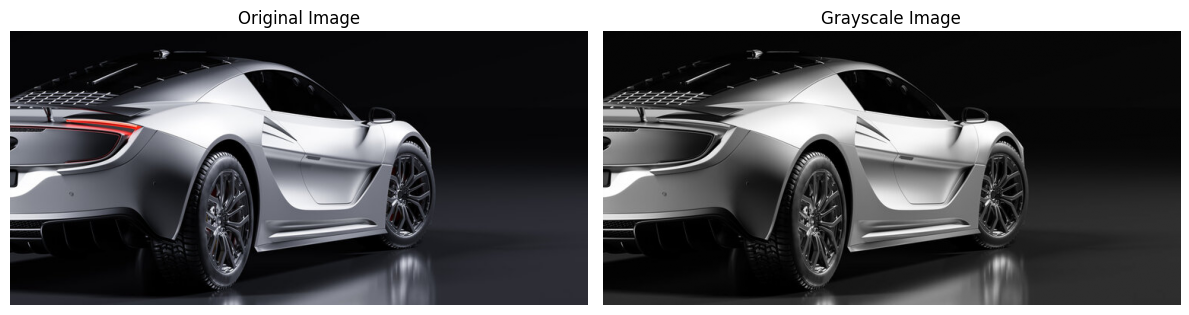

In [78]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image
image = cv2.imread("./img02.jpg")

# Convert the image from BGR to RGB format
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert the image to grayscale
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

H, W, C = image.shape
print(f"Image dimensions: {H}x{W}, Channels: {C}")

# Display the image using Matplotlib
fig, ax = plt.subplots(1, 2, figsize=(12, 16))
ax[0].imshow(image_rgb)
ax[0].set_title("Original Image")
ax[0].axis("off")  # Hide the axes
ax[1].imshow(image_gray, cmap="gray")
ax[1].set_title("Grayscale Image")
ax[1].axis("off")  # Hide the axes
fig.tight_layout()
plt.show()

### Keypoints using random sampling

Generated 300 random points.


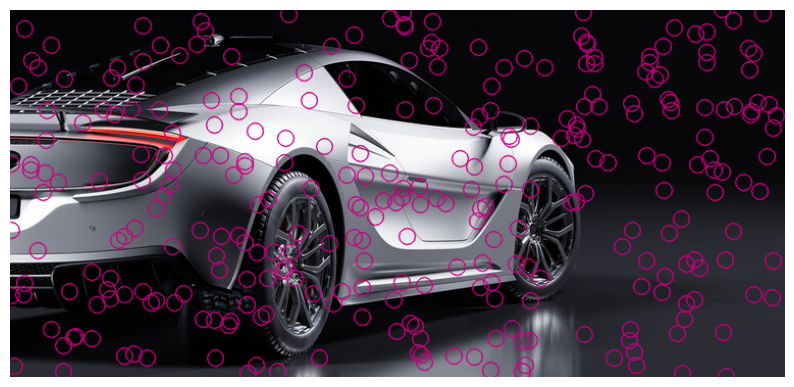

In [87]:
num_points = 300

np.random.seed(42)  # For reproducibility

# Create random coordinates for the points
x = np.random.randint(0, W, num_points)
y = np.random.randint(0, H, num_points)

points = np.column_stack((x, y)).astype(np.float32)
print(f"Generated {len(points)} random points.")

# Convert to cv2 keypoints
keypoints = [cv2.KeyPoint(
    x=pt[0],
    y=pt[1],
    size=16 # for visualization purposes
) for pt in points]

# Draw the keypoints on the image
image_with_keypoints = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    color=(200, 0, 128),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Display the image with keypoints
plt.figure(figsize=(10, 10))
plt.imshow(image_with_keypoints)
plt.axis("off")
plt.show()

In [90]:
# Use ORB to compute descriptors for the keypoints
orb = cv2.ORB_create()
keypoints, descriptors = orb.compute(image_gray, keypoints)
print(f"Computed descriptors for {len(descriptors)} keypoints.")

# Display the descriptor for the first keypoint
print("Descriptor for the first keypoint:")
print(f"Length: {len(descriptors[0])} elements")
print(descriptors[0])

Computed descriptors for 236 keypoints.
Descriptor for the first keypoint:
Length: 32 elements
[ 21  57 242   1 183 251 178  67 206 241  59  58  14 152 231 172 163  36
  94  19  21 249  12 148  24  76   1 119 237 109  89   7]


### Generate Keypoint using 15x15 Grid

Generated 240 grid keypoints.


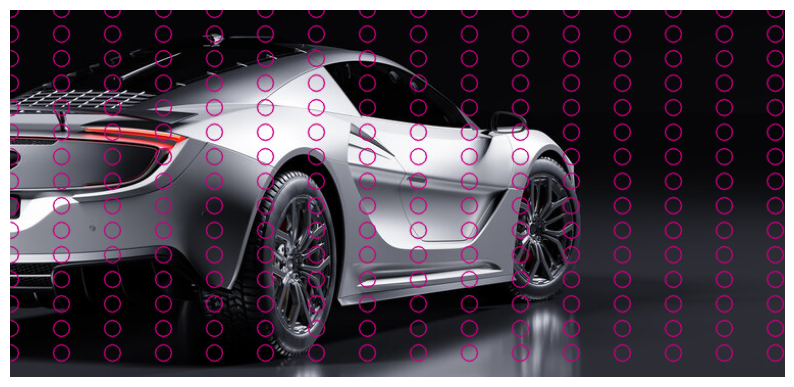

In [91]:
# Create a grid of points
grid_x_step = W // 15
grid_y_step = H // 15
grid_i, grid_j = np.meshgrid(
    np.arange(0, W, grid_x_step),
    np.arange(0, H, grid_y_step)
)

points = np.column_stack((grid_i.flatten(), grid_j.flatten())).astype(np.float32)

keypoints = [cv2.KeyPoint(
    x=pt[0],
    y=pt[1],
    size=16
) for pt in points]
print(f"Generated {len(keypoints)} grid keypoints.")

# Draw the keypoints on the image
image_with_keypoints = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    color=(200, 0, 128),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Display the image with keypoints
plt.figure(figsize=(10, 10))
plt.imshow(image_with_keypoints)
plt.axis("off")
plt.show()

In [92]:
# Use ORB to compute descriptors for the keypoints
orb = cv2.ORB_create()
keypoints, descriptors = orb.compute(image_gray, keypoints)
print(f"Computed descriptors for {len(descriptors)} keypoints.")

# Display the descriptor for the first keypoint
print("Descriptor for the first keypoint:")
print(f"Length: {len(descriptors[0])} elements")
print(descriptors[0])

Computed descriptors for 168 keypoints.
Descriptor for the first keypoint:
Length: 32 elements
[  0   0  64   0  32   0   0   0   0   8  16  32   0   0 128   0   2   0
   4   0   0   0   0   0   0   0  32 128   4   0   0   1]


### Generate Keypoints using a detector

Detected 415 SIFT keypoints.


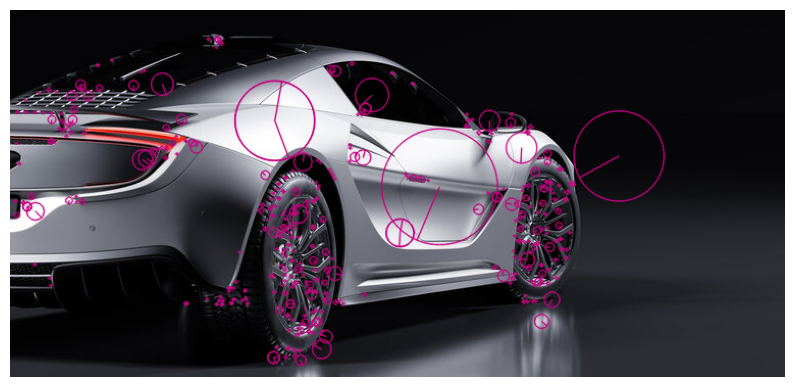

In [97]:
# Create SIFT keypoints detector
sift = cv2.SIFT_create()

# Detect keypoints
keypoints = sift.detect(image_gray, None)
print(f"Detected {len(keypoints)} SIFT keypoints.")

# Draw the keypoints on the image
image_with_keypoints = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    color=(200, 0, 128),
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Display the image with keypoints
plt.figure(figsize=(10, 10))
plt.imshow(image_with_keypoints)
plt.axis("off")
plt.show()

In [ ]:
# Describe the keypoints using SIFT
sift = cv2.SIFT_create()
keypoints, descriptors = sift.compute(image_gray, keypoints)
print(f"Computed descriptors for {len(descriptors)} keypoints.")

# Display the descriptor for the first keypoint
print("Descriptor for the first keypoint:")
print(f"Length: {len(descriptors[0])} elements")
print(descriptors[0])

Computed descriptors for 415 keypoints.
Descriptor for the first keypoint:
Length: 128 elements
[ 12.  17.  10.  36.  47.   1.   0.   0.  98. 161. 118.  10.   1.   0.
   0.   0.  18. 106. 161.   4.   0.   0.   1.   0.   0.   8. 161.  12.
   0.   0.   1.   0.   4.   3.   7.  61. 122.   2.   0.   1.  48.  52.
  67.  19.  11.   0.   7.  43.   9.  19. 161.   3.   0.   0.  74.  37.
   0.   0. 134.   7.   0.   6.  91.   2.   8.   2.   0.   7. 161.  12.
   0.   0. 140.  16.   0.   2.  17.   0.   1.  15.  55.   4.   0.   0.
   0.   0.  21.  21.   2.   0.   0.   0.   1.   4.  30.   2.   1.   0.
   0.   0.  52.   6.   0.   0.  28.   5.   0.   0.   5.   0.   0.   0.
  12.   2.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.]


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/johnpolsh/github/inf692/.env/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/johnpolsh/github/inf692/.env/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/johnpolsh/github/inf692/.env/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/johnpolsh/github/inf692/.env/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/johnpolsh/github/inf692/.env/lib/python3.11/site-packages/ipyker